# **Synthetic Controls**
***Date posted**: Oct. 5, 2026, **Last edited**: Oct. 5, 2026*

Punongbayan and de Dios argued that The Marcos regime worsened the economic situation of the country, with the effects reverberating in the current era, through a wanton accumulation of debt. The term "worsen" implies that there is a comparison made at a simple baseline

## **Causal Inference in a nutshell**

We consider the case of a **binary treatment**; that is, a group is either treated or not. Let $Y$ be the observed outcome and $T\in\{0,1\}$ denote whether the group is untreated (control) or treated. One useful concept is that of the *potential outcome*: whether this outcome is realized or not depends on what group it belongs to. More explicitly, $Y_0$ is the outcome *if* the group is untreated, and $Y_1$ is the outcome *if* the group is treated. Now that we have the variables defined, we can talk about calculations.

For an individual unit, the treatment effect is simply $\tau_i = Y_{1i}-Y_{0i}$. Here lies the problem so crucial that it is regarded as the **fundamental problem of causal inference**: we can only observe one of the potential outcomes, the **realized outcome**. For example, an evolving unit has, under the hood, two potential outcomes for a measurement done at a certain point in time: $Y_0 = 25$ and $Y_1 = 50$. If this unit is in the treatment group, then we observe $Y=50$. We would not have known the other outcome, which is aptly named the **counterfactual outcome**. Causal inference constitutes a family of methods for learning about the unobservable. We will set aside this problem for now and define several quantities:

To quantify the **average treatment effect**, we compare the two potential outcomes:
$$\text{ATE} = \mathbb{E}[Y_1-Y_0]$$

If we just want the **average treatment effect on the treated**, we calculate the conditional mean:

$$\text{ATT} = \mathbb{E}[Y_1-Y_0|T=1].$$

Now, there is a statistical caution that **association does not imply causation**. Just because the treated group has a different aggregate outcome compared to the untreated group doesn't necessarily imply that the treatment caused the difference. We then ask: when does association imply causation? First, association is quantified as
$$\mathbb{E}[Y|T=1]-\mathbb{E}[Y|T=0].$$
We can decompose this in terms of potential outcomes.

\begin{align*}
\mathbb{E}[Y|T=1]-\mathbb{E}[Y|T=0]&=\mathbb{E}[Y_1|T=1]-\mathbb{E}[Y_0|T=0].
\end{align*}

We can further expand this by adding zero:
$\mathbb{E}[Y_0|T=1]-\mathbb{E}[Y_0|T=1]$, which represents the difference between the counterfactual outcome of the treatment group and itself.

\begin{align*}
\mathbb{E}[Y|T=1]-\mathbb{E}[Y|T=0]&=\mathbb{E}[Y_1|T=1]-\mathbb{E}[Y_0|T=0]+\mathbb{E}[Y_0|T=1]-\mathbb{E}[Y_0|T=1],\\
&=\mathbb{E}[Y_1-Y_0|T=1]+(\mathbb{E}[Y_0|T=1]-\mathbb{E}[Y_0|T=0]).
\end{align*}

Note that the first term, $\mathbb{E}[Y_1-Y_0|T=1]$, is just the ATT. This term is causal because it represents the difference in outcomes for the treated group under two hypothetical treatment states. The second term, however, prevents the causal nature from being inherited by the left-hand side. The term $\mathbb{E}[Y_0|T=1]-\mathbb{E}[Y_0|T=0]$ is the **bias**. To zero in on causality, one must remove bias so that the observed difference in means identifies the ATT:

$$\mathbb{E}[Y_0|T=1]=\mathbb{E}[Y_0|T=0].$$

To put this in perspective, suppose we want to determine the effects of tablets on the academic performance of students. We design an experiment where the treatment group, the group that we will give tablets to, is composed of private school students. The control group is composed of public school students. Suppose we found out that the treatment group has significantly higher grades than the control group. Shall we conclude that tablets improve academic performance? The decomposition of association urges us to ask: what is the performance of the treatment group, the private school students, had we not given them tablets $(\mathbb{E}[Y_0|T=1])$, and how does it compare to that of the public school students $(\mathbb{E}[Y_0|T=0])$? It might be that even without tablets, the private school students are more likely to perform better since they are also more likely to afford tutors.

Fixing the problem of bias is straightforward: do **randomized experiments**. Pool the public and private school students and randomly assign whether they should receive treatment or not. Random assignment makes the treatment and control groups comparable, in expectation, with respect to their potential outcomes. However, we are not living in an ideal world where we can do just that. Fortunately, causal inference textbooks address such questions. For now, assuming that bias is effectively eliminated, we still have the fundamental problem.

## **Constructing the unobservable**

The aim of Punongbayan et al. was to "quantify the effect of the debt and economic crisis on the Philippines' growth trajectory" in the early 1980s. Quantifying the effect, however, means finding the deviation from a certain baseline. In other words, if we want to know, for example, how different the country is in 2016 (in terms of real GDP), we want to find $\tau_{2016}=Y_{1,2016}-Y_{0,2016}$. The second term is counterfactual. How would we know the counterfactual? We do not know what the real GDP of the country would have been had the Marcos regime not accumulated a staggering amount of debt at the worst possible moment. Should we compare it with another country then? But no country is more similar to the Philippines than the Philippines itself. There are political and cultural dynamics to be taken into account for each individual country. The **synthetic control method** (SCM) says the answer is both. We compare the Philippines to itself by reconstructing it from similar neighbors where the debt crisis did not happen.

Let $\{Y_{it}\}_{i=1}^{J+1}$ be the set of units at time $t$, whose first element, $Y_{1t}$, is the treated unit, and the remaining $J$ units constitute the **donor pool**. The counterfactual outcome for $Y_{1t}$ is

$$\hat{Y}^N_{1t}=\sum_{i=2}^{J+1}w_i^*Y_{it}.$$

In matrix notation,

$$\mathbf{\hat{Y}}^N=\mathbf{Y}\mathbf{w}^*$$

where $\mathbf{Y}$ is an $N\times J$ matrix consisting of the donor pool, with $N$ observation times. We set $T_0$ to be the last pre-intervention period. The set $\{w_i^*\}_{i=2}^{J+1}$ contains $J$ values that gives the optimal set of weights for constructing the synthetic counterpart of the treated unit. These weights are chosen to minimize the discrepancy between the treated unit and its synthetic counterpart during the pre-intervention period.

## **Interpolation**

It might be tempting to consider the counterfactual construction as a regression problem. The problem with this is that the regression coefficients can assign negative weights or weights greater than one, allowing the synthetic control to extend beyond the **convex hull** of the donors. This is called **extrapolation**. We don't want that, since an unconstrained regression can also overfit the pre-treatment period while producing a poor synthetic counterpart post-treatment. We will **interpolate** instead. Specifically, we want to make the synthetic control a **convex combination** of the donors. This means, on top of being a linear combination, imposing the following conditions:

1. The weights must be non-negative: $w_i\geq 0$.
2. The weights must sum up to one: $\sum_i w_i = 1$.

The set of convex combinations of a set of observations is called the **convex hull**. To visualize this, we consider two points in two dimensions, say $(1,2)$ and $(3,4)$. The convex hull is the line segment between these two points, inclusive of them. This line segment can be parametrized with $0\leq w\leq 1$ and described by
$$(1,2)w+(3,4)(1-w).$$
Observe that $w_1=w$ and $w_2 = 1-w$ and that $w_1+w_2 = 1$.

If we have three points instead, the convex hull is the triangle formed by these points. If the point we want to construct lies outside the convex hull, it instead chooses the point in the convex hull that is *closest* to the point of interest. In the case of the triangle defined by points $A$, $B$, and $C$, the closest point might lie in the line segment between $A$ and $B$. Therefore, interpolation sets the coefficient associated with $C$ to $0$ as it is unnecessary. This idea can be carried over to $N$ dimensions with the convex hull defined by $J$ points, setting the coefficients of points that are irrelevant for the closest boundary face of the hull to $0$.

## **Searching for $\mathbf{w}^*$**

The search for optimal weights is subject to quadratic optimization:

$$\mathbf{w}^*=\operatorname*{argmin}_{\mathbf{w}}\,\left(\mathbf{X}_1 - \mathbf{X}_0 \mathbf{w}\right)^T\mathbf{V}\left(\mathbf{X}_1 - \mathbf{X}_0 \mathbf{w}\right)$$

subject to

$$w_i\geq 0,\qquad \sum_i w_i=1.$$

Here, $\mathbf{X}_1$ is the vector of pre-intervention characteristics of the treated unit, $\mathbf{X}_0$ is the corresponding matrix for the donor pool, and $\mathbf{V}$ is an $N\times N$ positive semi-definite matrix, often referred to as the **importance matrix**. The choice of $\mathbf{V}$ is crucial since the resulting weights depend on it. If one declines to supply $\mathbf{V}$, it can instead be chosen based on how well the resulting synthetic control predicts the treated unit during the pre-intervention period by minimizing the MSPE:

$$\text{MSPE}=\frac{1}{N}\left\lVert\mathbf{Y}_1-\mathbf{Y}_0\mathbf{w}^*\right\rVert^2.$$

More explicitly, since $\mathbf{w}^*$ depends on $\mathbf{V}$, we can write

$$\mathbf{w}^*(\mathbf{V})=\operatorname*{argmin}_{\mathbf{w}}\,\left(\mathbf{X}_1 - \mathbf{X}_0 \mathbf{w}\right)^T\mathbf{V}\left(\mathbf{X}_1 - \mathbf{X}_0 \mathbf{w}\right),$$

and then choose

$$\mathbf{V}^*=\operatorname*{argmin}_{\mathbf{V}}\,\frac{1}{N}\left\lVert\mathbf{Y}_1-\mathbf{Y}_0\mathbf{w}^*(\mathbf{V})\right\rVert^2.$$

The algorithm becomes simple: supply $\mathbf{V}$, get the associated $\mathbf{w}^*$, calculate the MSPE, and repeat until we get $\mathbf{V}^*$ from the lowest MSPE.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.optimize import minimize

We load the PWT v.10.01 data. We also redefine `emp` to be `emp/pop`

In [8]:
pwt = pd.read_csv('data/pwt.csv').query('1960 <= year <= 2019')
pwt['emp'] /= pwt['pop']

ea_countries = ["CHN","HKG","JPN","KOR","PRK","MNG","TWN","BRN","KHM","IDN","LAO","MYS","MMR","PHL","SGP","THA","TLS","VNM"]

data = pwt[pwt.countrycode.isin(ea_countries)]
data = data[data.groupby('countrycode')['rgdpna'].transform('count').eq(60)].reset_index(drop=True) # remove incomplete real gdp data

In [9]:
label, treated_label, T0, target = 'countrycode', 'PHL', 1980, 'rgdpna'
cov = ['avh', 'csh_c', 'emp', 'hc', 'labsh', 'rnna', 'rtfpna']

pre = data[data.year < T0]

# Country-mean imputation
data[cov] = data[cov].fillna(data.groupby(label)[cov].transform('mean'))

full = data.pivot(index='year', columns=label, values=target).sort_index()
Y1_full = full[treated_label].to_numpy()
Y0_full = full.drop(columns=treated_label).to_numpy()

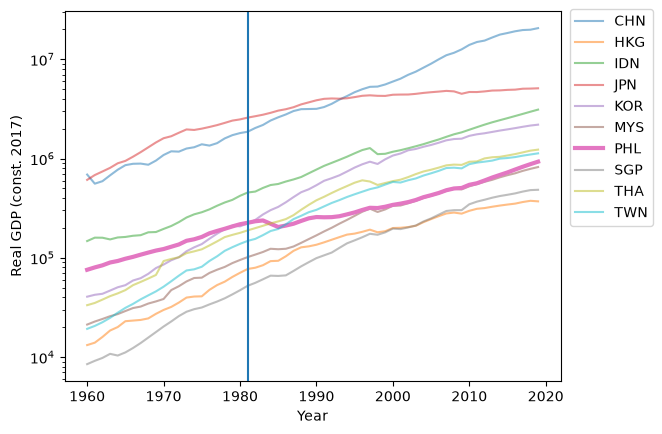

In [38]:
for cty in full.columns:
    if cty == treated_label:
        plt.plot(full[cty], label = cty, lw = 3)
    else:
        plt.plot(full[cty], label = cty, alpha = 0.5)

plt.axvline(T0+1)
plt.yscale('log')
plt.xlabel('Year')
plt.ylabel('Real GDP (const. 2017)')
plt.legend(bbox_to_anchor=(1.20, 1.025), loc='upper right')

plt.show()

In [ ]:
pre = data[data.year < T0].pivot(index='year', columns=label, values=target).sort_index()
Y1 = pre[treated_label].to_numpy()
Y0 = pre.drop(columns=treated_label).to_numpy()

w_vals = np.ones(Y0.shape[1]) / Y0.shape[1]
residual = Y1 - Y0 @ w_vals